# Notebook 1 — Concept: why tidal currents carry energy

Before running any code we need to be clear about what the model computes and why. This notebook explains the physics behind the resource estimate: where tides come from, how the free surface is reconstructed from harmonic constituents, how elevation is turned into a current by the shallow-water equations, and why the resulting kinetic-energy flux is what a tidal-stream turbine cares about. Each idea is accompanied by a small code check you can run and modify. The full derivation and methodology live in `../concepts/MODEL.md`; this notebook is the intuitive version.


## Learning objectives

- Understand astronomical tidal forcing and the M2/S2/K1/O1 constituents.
- Appreciate the spring–neap cycle and why runs last ≥ 15 days.
- See why power density scales as ½ρU³.
- Explain how a tidal-stream turbine converts the current into power.
- Understand the funnel effect and the screening cascade.


## 1.1 Tides are a sum of harmonics

The ocean is not forced by one single wave. Tides are long-period surface gravity waves generated by the gravitational pull of the Moon and the Sun as the Earth rotates beneath them. The dominant component is the **semi-diurnal lunar tide (M2)** at 12.42 hours — the time between successive passes of the Moon over a given meridian. Because the tidal wave is forced at ocean-basin scale it propagates as a shallow-water wave: even in the deepest ocean (~5 km) the wavelength vastly exceeds the depth, so the whole water column moves in phase.

Real tides are a **superposition** of such harmonics, each with an amplitude and a phase locked to an astronomical period. At any point the free surface is the sum:

$$\eta(t) = \sum_k A_k \cos(\omega_k t + \phi_k)$$

where $A_k$ is the amplitude in metres, $\omega_k = 2\pi/T_k$ the angular frequency, and $\phi_k$ the phase. The four constituents below account for ~80–90% of tidal variability in most of the world ocean, which is why the project forces the model with them by default:

| Constituent | Origin | Period | Typical amplitude (PH) |
|-------------|--------|--------|-------------------------|
| M2 | Principal lunar semi-diurnal | 12.42 h | 0.3–1.0 m |
| S2 | Principal solar semi-diurnal | 12.00 h | 0.1–0.3 m |
| K1 | Luni-solar diurnal | 23.93 h | 0.2–0.5 m |
| O1 | Principal lunar diurnal | 25.82 h | 0.1–0.3 m |

The cell below reconstructs $\eta(t)$ from all four constituents and plots the total alongside each individual harmonic. Notice how the slow diurnal constituents (K1, O1) act as a slowly varying baseline underneath the fast semi-diurnals (M2, S2) — this is the same summation the model performs at every open-boundary cell.


M2: A = 0.50 m, T = 12.4206 h
S2: A = 0.20 m, T = 12.0000 h
K1: A = 0.25 m, T = 23.9345 h
O1: A = 0.15 m, T = 25.8193 h


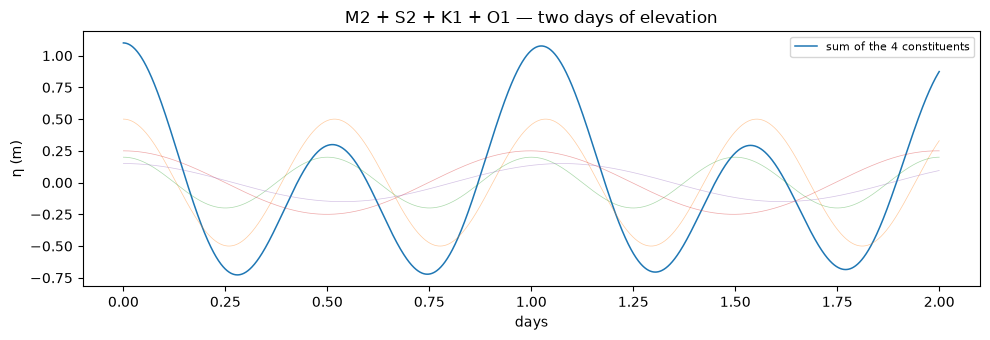

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

t_h = np.linspace(0.0, 48.0, 2000)   # two days, in hours

constituents = [
    ('M2', 0.50, 12.4206012),   # principal lunar semi-diurnal
    ('S2', 0.20, 12.0),         # principal solar semi-diurnal
    ('K1', 0.25, 23.9344696),   # luni-solar diurnal
    ('O1', 0.15, 25.8193417),   # principal lunar diurnal
]

eta = np.zeros_like(t_h)
for name, amp, period in constituents:
    eta += amp * np.cos(2 * np.pi * t_h / period)
    print(f'{name}: A = {amp:.2f} m, T = {period:.4f} h')

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t_h / 24.0, eta, lw=1.1, label='sum of the 4 constituents')
for name, amp, period in constituents:
    ax.plot(t_h / 24.0, amp * np.cos(2 * np.pi * t_h / period),
            lw=0.5, alpha=0.4)
ax.set_xlabel('days')
ax.set_ylabel('η (m)')
ax.set_title('M2 + S2 + K1 + O1 — two days of elevation')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()


![Superposition of M2, S2, K1 and O1 over two days.](images/fig_tidal_superposition.png)


## 1.2 Power density: the ½ρU³ law

A tidal-stream turbine converts **kinetic** energy. The quantity that matters is the instantaneous power per unit swept area — the kinetic-energy flux through the rotor disk:

$$P = \tfrac{1}{2} \rho U^3 \qquad [\text{W/m}^2]$$

with $\rho = 1025$ kg/m³ (seawater) and $U = \sqrt{u^2+v^2}$ the depth-averaged current speed. The cube follows from three simple factors:

1. Kinetic energy per unit volume: $\tfrac{1}{2}\rho U^2$.
2. Volume flux per unit area per unit time: $U$ (m³/s per m²).
3. Product: $\tfrac{1}{2}\rho U^2 \times U = \tfrac{1}{2}\rho U^3$.

The cubic dependence is the defining feature of tidal-stream resource assessment: **doubling the speed gives eight times the power**. A site at 2.5 m/s is not 25% better than one at 2.0 m/s — it yields almost double the power density. This is why accurate velocity prediction matters so much for site selection. Run the two cells below: the first tabulates the law, the second plots it and highlights the 1 → 2 m/s jump.


In [2]:
RHO = 1025.0   # kg/m^3 seawater
print(' U [m/s]    P [W/m^2]')
for u in (0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0):
    print(f'  {u:4.1f}    {0.5 * RHO * u**3:9.1f}')


 U [m/s]    P [W/m^2]
   0.5         64.1
   1.0        512.5
   1.5       1729.7
   2.0       4100.0
   2.5       8007.8
   3.0      13837.5
   4.0      32800.0


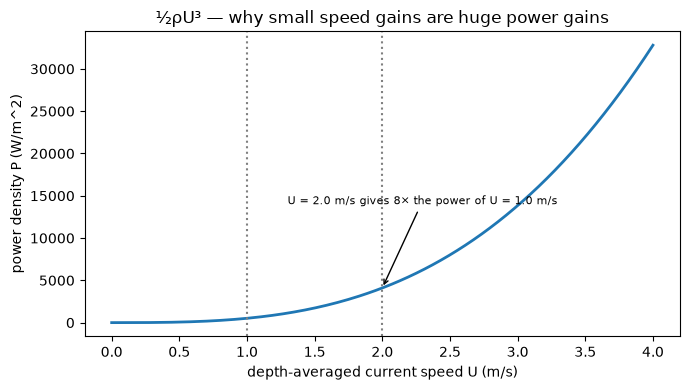

In [3]:
import numpy as np
import matplotlib.pyplot as plt

RHO = 1025.0   # kg/m^3 seawater
u = np.linspace(0.0, 4.0, 200)
p = 0.5 * RHO * u**3

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(u, p, lw=2)
for uu in (1.0, 2.0):
    ax.axvline(uu, ls=':', color='grey')
ax.annotate('U = 2.0 m/s gives 8× the power of U = 1.0 m/s',
            xy=(2.0, 0.5 * RHO * 8.0), xytext=(1.3, 14000),
            arrowprops=dict(arrowstyle='->'), fontsize=8)
ax.set_xlabel('depth-averaged current speed U (m/s)')
ax.set_ylabel('power density P (W/m^2)')
ax.set_title('½ρU³ — why small speed gains are huge power gains')
plt.tight_layout()
plt.show()


![Power density grows with the cube of current speed (½ρU³).](images/fig_cubic_power.png)


## 1.3 How tidal-stream turbines work

So far we have built up the resource: the free surface, the current it drives, and the kinetic-energy flux ½ρU³ that travels with it. The machine that harvests that flux is a **tidal in-stream turbine** — the underwater cousin of a wind turbine. A rotor of blades spins as the current pushes past them, the hub turns a generator, and electricity is cabled to shore.

**The energy chain.** The current does work on the rotor. The rotor converts the kinetic energy of the moving water into rotational mechanical energy, the shaft spins a generator (often through a gearbox, sometimes direct-drive), and the generator produces AC electricity that a subsea cable carries to the grid. The whole chain is driven by a single input: the speed of the water through the swept area.

**Swept area.** A rotor of diameter $D$ sweeps $A = \pi D^2/4$. The kinetic energy arriving at the rotor per second is the flux through that area:

$$P_{\text{available}} = \tfrac{1}{2}\rho A U^3$$

**The Betz limit.** A rotor cannot stop the water — the flow must keep moving, so only a fraction of the incoming kinetic energy can be captured. Momentum theory (the same argument that limits wind turbines) caps that fraction at $16/27 \approx 59.3\%$, the **Betz limit**. Real turbines reach a power coefficient $C_p \approx 0.35\text{–}0.45$, so the practical output is:

$$P = \tfrac{1}{2}\rho A U^3 \, C_p$$

Everything that made $U^3$ special for the resource is doubled down here: a turbine at a 2.5 m/s site extracts roughly eight times the power of one at a 1.25 m/s site. Turbines are tuned to the *range* of speeds at a specific strait.

**The power curve.** A turbine operates in three regimes:

| Regime | Condition | Behaviour |
|--------|-----------|-----------|
| Below cut-in | $U < U_{\text{cut-in}}$ | No power; the current is too weak to turn the rotor usefully |
| Cubic ramp | $U_{\text{cut-in}} \le U < U_{\text{rated}}$ | Output grows as $U^3$ |
| Rated plateau | $U_{\text{rated}} \le U < U_{\text{cut-out}}$ | Output held at rated power (blade pitch / stall control) |
| Cut-out | $U \ge U_{\text{cut-out}}$ | Turbine brakes to protect the machine |

Typical tidal devices have cut-in ~0.5–1 m/s, rated speed ~1.8–2.5 m/s, and cut-out ~3–4 m/s.

**Two-way currents.** Unlike wind, the tide reverses — flood then ebb, twice a day. Rotors therefore either pitch their blades to face the flow or are symmetric and work in both directions; some designs yaw the whole nacelle. The reversal also means a turbine is idle for part of every tidal cycle, which is why the *mean* output over a spring–neap cycle — not the peak — determines the **capacity factor** (mean output ÷ rated power). Tidal sites typically deliver capacity factors of ~20–40%.

The two cells below put numbers on this: the first computes the available flux, the Betz limit, and the output of a representative rotor; the second plots its full power curve. The project's web layer (Notebook 5) ships a curated set of real turbines with exactly this kind of power-curve model.


In [4]:
import numpy as np

rho = 1025.0
D = 20.0                      # rotor diameter (m)
A = np.pi * (D / 2) ** 2      # swept area (m^2)
Cp = 0.40                     # power coefficient (Betz = 16/27 ≈ 0.593)

U_rated = 2.4                 # speed at rated power (m/s)
P_rated = 0.5 * rho * A * U_rated ** 3 * Cp

print(f'swept area A          : {A:7.1f} m^2')
print(f'available flux @2.0   : {0.5 * rho * A * 2.0**3 / 1e3:7.1f} kW')
print(f'Betz limit 16/27      : {16 / 27:7.3f}')
print(f'output @2.0 (Cp=0.40) : {0.5 * rho * A * 2.0**3 * Cp / 1e3:7.1f} kW')
print(f'rated power @{U_rated:.1f}   : {P_rated / 1e3:7.1f} kW')


swept area A          :   314.2 m^2
available flux @2.0   :  1288.1 kW
Betz limit 16/27      :   0.593
output @2.0 (Cp=0.40) :   515.2 kW
rated power @2.4   :   890.3 kW


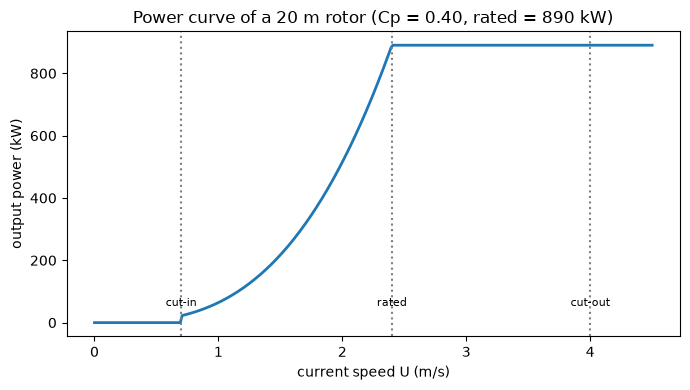

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rho, D, Cp = 1025.0, 20.0, 0.40
A = np.pi * (D / 2) ** 2
U_cut_in, U_rated, U_cut_out = 0.7, 2.4, 4.0
P_rated = 0.5 * rho * A * U_rated ** 3 * Cp

u = np.linspace(0.0, U_cut_out + 0.5, 300)
p = np.where(u < U_cut_in, 0.0,
             np.where(u < U_rated, 0.5 * rho * A * u**3 * Cp, P_rated))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(u, p / 1e3, lw=2)
ymax = p.max() / 1e3
for x, lab in [(U_cut_in, 'cut-in'), (U_rated, 'rated'),
               (U_cut_out, 'cut-out')]:
    ax.axvline(x, ls=':', color='grey')
    ax.text(x, 0.06 * ymax, lab, ha='center', fontsize=8)
ax.set_xlabel('current speed U (m/s)')
ax.set_ylabel('output power (kW)')
ax.set_title(f'Power curve of a {D:.0f} m rotor (Cp = {Cp:.2f}, '
              f'rated = {P_rated / 1e3:.0f} kW)')
plt.tight_layout()
plt.show()


![Power curve of a 20 m rotor with cut-in, rated and cut-out.](images/fig_turbine_power_curve.png)


## 1.4 Spring–neap modulation

M2 and S2 have nearly the same period — 12.42 h versus 12.00 h — so their sum produces a **beat**: an envelope whose amplitude grows and decays as the two components drift in and out of phase. When they are in phase the range is maximum (**spring tide**, big currents); when they are half a period apart the range is minimum (**neap tide**, weak currents).

The beat period is the inverse of the frequency difference:

$$T_{\text{beat}} = \frac{1}{1/T_{S2} - 1/T_{M2}} \approx 354\text{ h} \approx 14.77\text{ days}$$

This is why the simulation runs for **at least 15 days**. A shorter run risks sampling only springs (over-estimating the resource) or only neaps (under-estimating it). The cells below compute the beat period and plot the full 30-day envelope so you can see the springs and neaps by eye.


In [6]:
import numpy as np

T_M2, T_S2 = 12.4206012, 12.0   # hours
T_beat = 1.0 / (1.0 / T_S2 - 1.0 / T_M2)
print(f'beat period: {T_beat:6.1f} h = {T_beat / 24.0:5.2f} days')
print(f'a 15-day run covers {15.0 / (T_beat / 24.0):.1f} beat(s)')


beat period:  354.4 h = 14.77 days
a 15-day run covers 1.0 beat(s)


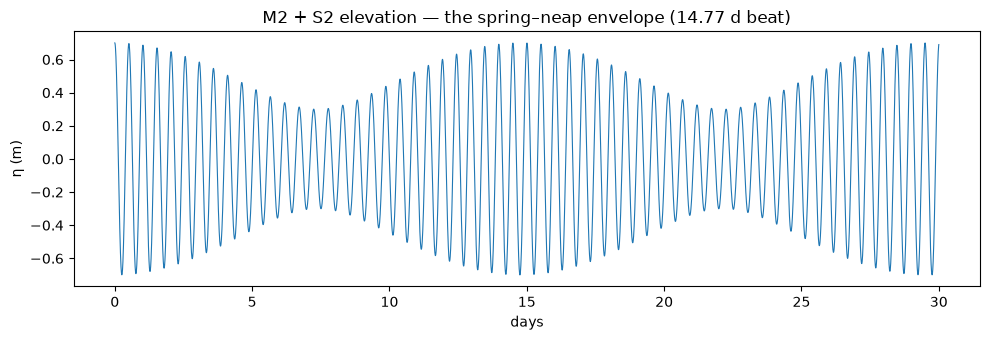

In [7]:
import numpy as np
import matplotlib.pyplot as plt

t_h = np.linspace(0.0, 30.0 * 24.0, 6000)          # 30 days in hours
eta = (0.5 * np.cos(2 * np.pi * t_h / 12.4206012)
       + 0.2 * np.cos(2 * np.pi * t_h / 12.0))    # M2 + S2

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(t_h / 24.0, eta, lw=0.8)
ax.set_xlabel('days')
ax.set_ylabel('η (m)')
ax.set_title('M2 + S2 elevation — the spring–neap envelope (14.77 d beat)')
plt.tight_layout()
plt.show()


![The M2 + S2 beat produces a 14.77-day spring–neap envelope.](images/fig_spring_neap.png)


## 1.5 From elevation to current

A tide gauge measures water level, but a turbine extracts kinetic energy from the **current**. How does a one-metre surface slope become a multi-metre-per-second flow? That is the job of the depth-averaged shallow-water equations.

**Continuity** conserves volume: if water converges into a cell the surface rises:

$$
\frac{\partial \eta}{\partial t}
+ \frac{\partial}{\partial x}(h u)
+ \frac{\partial}{\partial y}(h v) = 0
$$

**Momentum** is Newton's second law: a surface slope is a pressure gradient that accelerates water downhill, balanced by friction and Coriolis:

$$
\frac{\partial u}{\partial t}
= -g\,\frac{\partial \eta}{\partial x}
 + f v - \frac{C_d}{h}\,|u|\,u
$$

| Term | Physics | When it matters |
|------|---------|-----------------|
| Pressure gradient $-g\,\partial\eta/\partial x$ | Water accelerates from high η to low η — the primary driver | Always |
| Coriolis $f v$ | Earth's rotation deflects flow to the right (N hemisphere) | Scales > 10 km |
| Bottom friction $C_d\,|u|\,u/h$ | Seabed shear stress, the main energy sink | Dominant in shallow channels |

Bottom friction is inversely proportional to depth ($1/h$): in deep water the tide propagates almost as a free wave, while in a shallow channel friction dominates and caps the current. That is why shallow channels are lossy and why depth is such a strong predictor of current speed.

The code cell below integrates the momentum balance for a single channel (no Coriolis, no advection) forced by a sinusoidal along-channel slope. After a spin-up of a few M2 periods the current settles into a periodic response whose amplitude matches the prediction of Lorentz linearisation, $|u|u \approx (8/3\pi)\,U\,u$ — a concrete check that the equation really does turn elevation into current.


In [8]:
import numpy as np

g, h, cd, S0 = 9.81, 50.0, 0.0025, 1e-5
T = 12.4206012 * 3600.0          # M2 period in seconds
omega = 2 * np.pi / T

# Lorentz linearisation: |u|u ≈ (8/3π) U u  ⇒  solve
#   (ωU)^2 + [(8/3π)·(cd/h)·U^2]^2 = (g·S0)^2  for U
def residual(U):
    return ((omega * U) ** 2
            + ((8 / (3 * np.pi)) * (cd / h) * U ** 2) ** 2
            - (g * S0) ** 2)

lo, hi = 0.0, 10.0
for _ in range(100):
    mid = 0.5 * (lo + hi)
    if residual(mid) > 0:
        hi = mid
    else:
        lo = mid
U_lorentz = 0.5 * (lo + hi)

# numeric integration of  du/dt = -g·S0·cos(ωt) - (cd/h)·|u|·u
dt, dur = 5.0, 15.0 * T
t = np.arange(0.0, dur, dt)
u = 0.0
U = np.empty(t.size)
for i, ti in enumerate(t):
    u += dt * (-g * S0 * np.cos(omega * ti) - (cd / h) * abs(u) * u)
    U[i] = u

U_num = np.max(np.abs(U[int(0.7 * t.size):]))
print(f'Lorentz estimate : {U_lorentz:.3f} m/s')
print(f'numeric amplitude: {U_num:.3f} m/s')
print(f'ratio            : {U_num / U_lorentz:.2f}')


Lorentz estimate : 0.684 m/s
numeric amplitude: 0.682 m/s
ratio            : 1.00


## 1.6 The funnel effect and hotspots

Mass conservation $Q = A\,U$ (volume flux = cross-sectional area × speed) has a striking consequence. If a channel narrows from width $W_1$ to $W_2$ and shallows from $h_1$ to $h_2$, the same flux must squeeze through a smaller area, so the current accelerates:

$$U_2 \approx U_1 \, \frac{W_1}{W_2}\, \frac{h_1}{h_2}$$

This is the **funnel effect** — why straits are hotspots. The Philippine archipelago is exceptionally rich in these constriction sites because it sits at the junction of several tidal basins with different phases: the Pacific (large M2 amplitude), the South China Sea (smaller, different phase), the Sulu Sea (resonant, semi-enclosed), and the Celebes Sea. The phase differences between basins drive strong flows through the inter-island straits:

| Strait | Peak spring current | Power density (est.) |
|--------|---------------------|----------------------|
| San Bernardino Strait | 3–4 m/s | > 1000 W/m² |
| Surigao Strait | 2–3 m/s | 500–1000 W/m² |
| Basilan Strait | 2–2.5 m/s | 200–500 W/m² |
| Verde Island Passage | 1.5–2 m/s | 100–300 W/m² |

The code cell below runs an idealised funnel: it fixes the volume flux and shows how speed — and hence power density — jump as the channel narrows. The real model is more complex (friction and unsteadiness cap the acceleration), but this is the first-order mechanism that makes straits worth investigating.


In [9]:
# Idealised, frictionless funnel: Q = A·U is conserved
Q = 1.0e6                    # volume flux, m^3/s (illustrative)
W1, h1 = 10000.0, 50.0      # wide/deep channel: 10 km × 50 m
W2, h2 = 5000.0, 40.0       # narrow/shallow:   5 km × 40 m

U1 = Q / (W1 * h1)
U2 = Q / (W2 * h2)
print(f'wide channel   : U1 = {U1:5.2f} m/s')
print(f'narrow channel : U2 = {U2:5.2f} m/s')
print(f'speed-up       : {U2 / U1:4.1f}×')
print(f'power ratio    : {(U2 / U1) ** 3:5.1f}×   (power ∝ U³)')


wide channel   : U1 =  2.00 m/s
narrow channel : U2 =  5.00 m/s
speed-up       :  2.5×
power ratio    :  15.6×   (power ∝ U³)


![The funnel effect: Q = A·U means a narrowing channel accelerates the current.](images/fig_funnel_effect.png)


## 1.7 The screening cascade

The project deliberately does **not** try to resolve every strait at high resolution from day one. It uses a screening cascade that fails fast and fails cheap — each tier is more expensive, so only the sites that survive the previous tier move on:

```
Coarse Python model (this project's Phase A)
        │
        ▼
   Sites with P_mean > 200 W/m²  (hotspots.geojson)
        │
        ▼
   High-resolution TELEMAC-2D unstructured mesh (Phase B)
        │
        ▼
   Turbine-array CFD / actuator-disk modelling
        │
        ▼
   Geophysical / environmental surveys
        │
        ▼
   Pilot deployment
```

The screening model is **deliberately conservative**: coarse resolution and depth-averaging both *under-estimate* peak currents, so any site it flags as promising is almost certainly worth a closer look with the finer tools. The 200 W/m² threshold is the gateway between the first two tiers.


![The screening cascade: cheap coarse tiers first, expensive refinement only for survivors.](images/fig_screening_cascade.png)


## Next

Concepts are covered; move to [Notebook 2 — data](2.data.ipynb) to see what the project ingests and publishes.

---

[Index](README.md) · [← 0.setup.ipynb](0.setup.ipynb) · [2.data.ipynb →](2.data.ipynb)
